In [18]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.signal import welch


In [19]:
def moving_average(df, window):
    """Simple centered moving-average smoothing. window is in samples."""
    return df.rolling(window, min_periods=1, center=True).mean()


def lowpass_filter(df, cutoff_hz, sample_rate_hz, order=4):
    """Zero-phase Butterworth low-pass. cutoff_hz is the -3dB rolloff point;
    sample_rate_hz comes from the loaded signal (sig.sample_rate_hz /
    ct.sample_rate_hz), not a free parameter you have to guess."""
    nyquist = sample_rate_hz / 2
    b, a = butter(order, cutoff_hz / nyquist, btype="low")
    return df.apply(lambda col: filtfilt(b, a, col))

def plot_psd(series, sample_rate_hz, title=""):
    """Power spectral density (Welch's method) -- look at where a signal's
    energy actually lives before picking a lowpass cutoff, rather than
    guessing a round number."""
    freqs, power = welch(series, fs=sample_rate_hz, nperseg=4096)
    plt.figure(figsize=(10, 4))
    plt.semilogy(freqs, power)
    plt.xlabel("frequency (Hz)")
    plt.ylabel("power spectral density")
    plt.title(title)
    plt.show()


In [20]:
from data_loading import load_vibration_mat, load_current_temp_tdms


def plot_mat_data(path, subset=None, cutoff_hz=None, m_avg_window=None):
    path = Path(path)

    if path.suffix == ".mat":
        sig = load_vibration_mat(path)
        df = pd.DataFrame(sig.values, columns=sig.channel_names)
        sample_rate_hz = sig.sample_rate_hz
    elif path.suffix == ".tdms":
        ct = load_current_temp_tdms(path)
        n = min(len(ct.temperature), len(ct.current)) if len(ct.current) else len(ct.temperature)
        data = {f"temp_{name}": ct.temperature[:n, i] for i, name in enumerate(ct.temperature_channels)}
        data.update({f"current_{name}": ct.current[:n, i] for i, name in enumerate(ct.current_channels)})
        df = pd.DataFrame(data)
        sample_rate_hz = ct.sample_rate_hz
    else:
        raise ValueError(f"Unsupported file type: {path.suffix}")

    # Filter on the FULL signal first, subset after. filtfilt (and, to a
    # lesser extent, a rolling average) needs real data on both sides of a
    # point to avoid edge artifacts -- slicing first would make it treat the
    # subset boundary as if the recording actually ended there, producing a
    # fabricated edge-transient in the middle of a much longer real signal.
    if cutoff_hz is not None:
        df = lowpass_filter(df, cutoff_hz, sample_rate_hz)

    if m_avg_window is not None:
        df = moving_average(df, m_avg_window)

    if subset is not None:
        df = df.iloc[subset[0]:subset[1]]

    fig, axes = plt.subplots(len(df.columns), 1, figsize=(14, 3 * len(df.columns)), sharex=True)
    if len(df.columns) == 1:
        axes = [axes]
    for ax, col in zip(axes, df.columns):
        ax.plot(df.index, df[col], linewidth=0.8)
        ax.set_ylabel(col)
    axes[-1].set_xlabel("sample index")
    plt.suptitle(path.stem)
    plt.tight_layout()
    plt.show()

    return df


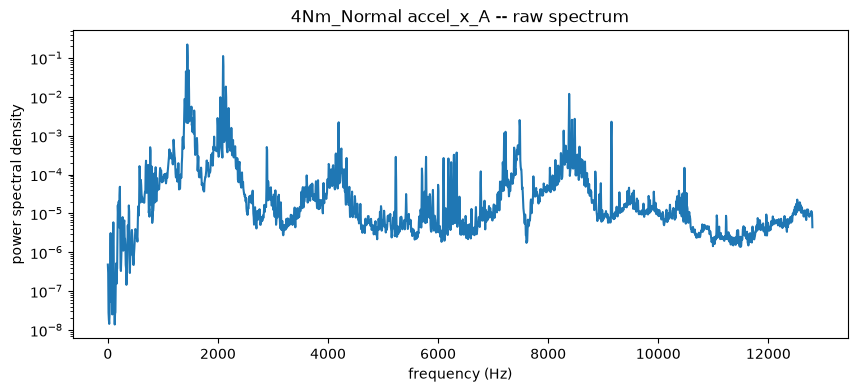

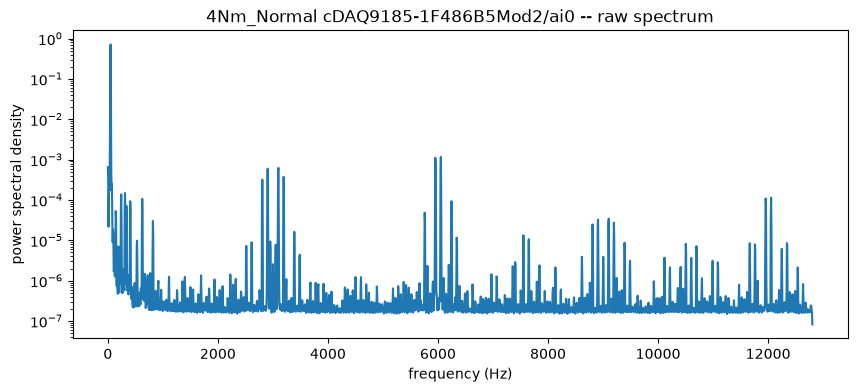

In [21]:
# Look at the spectrum before choosing a cutoff -- vibration vs. current
# have very different frequency content, so the same cutoff_hz is not
# automatically appropriate for both.
sig = load_vibration_mat("DataKAIST/vibration/4Nm_Normal.mat")
plot_psd(sig.values[:, 0], sig.sample_rate_hz, title=f"4Nm_Normal {sig.channel_names[0]} -- raw spectrum")

ct = load_current_temp_tdms("DataKAIST/current,temp/4Nm_Normal.tdms")
if ct.current_channels:
    plot_psd(ct.current[:, 0], ct.sample_rate_hz, title=f"4Nm_Normal {ct.current_channels[0]} -- raw spectrum")


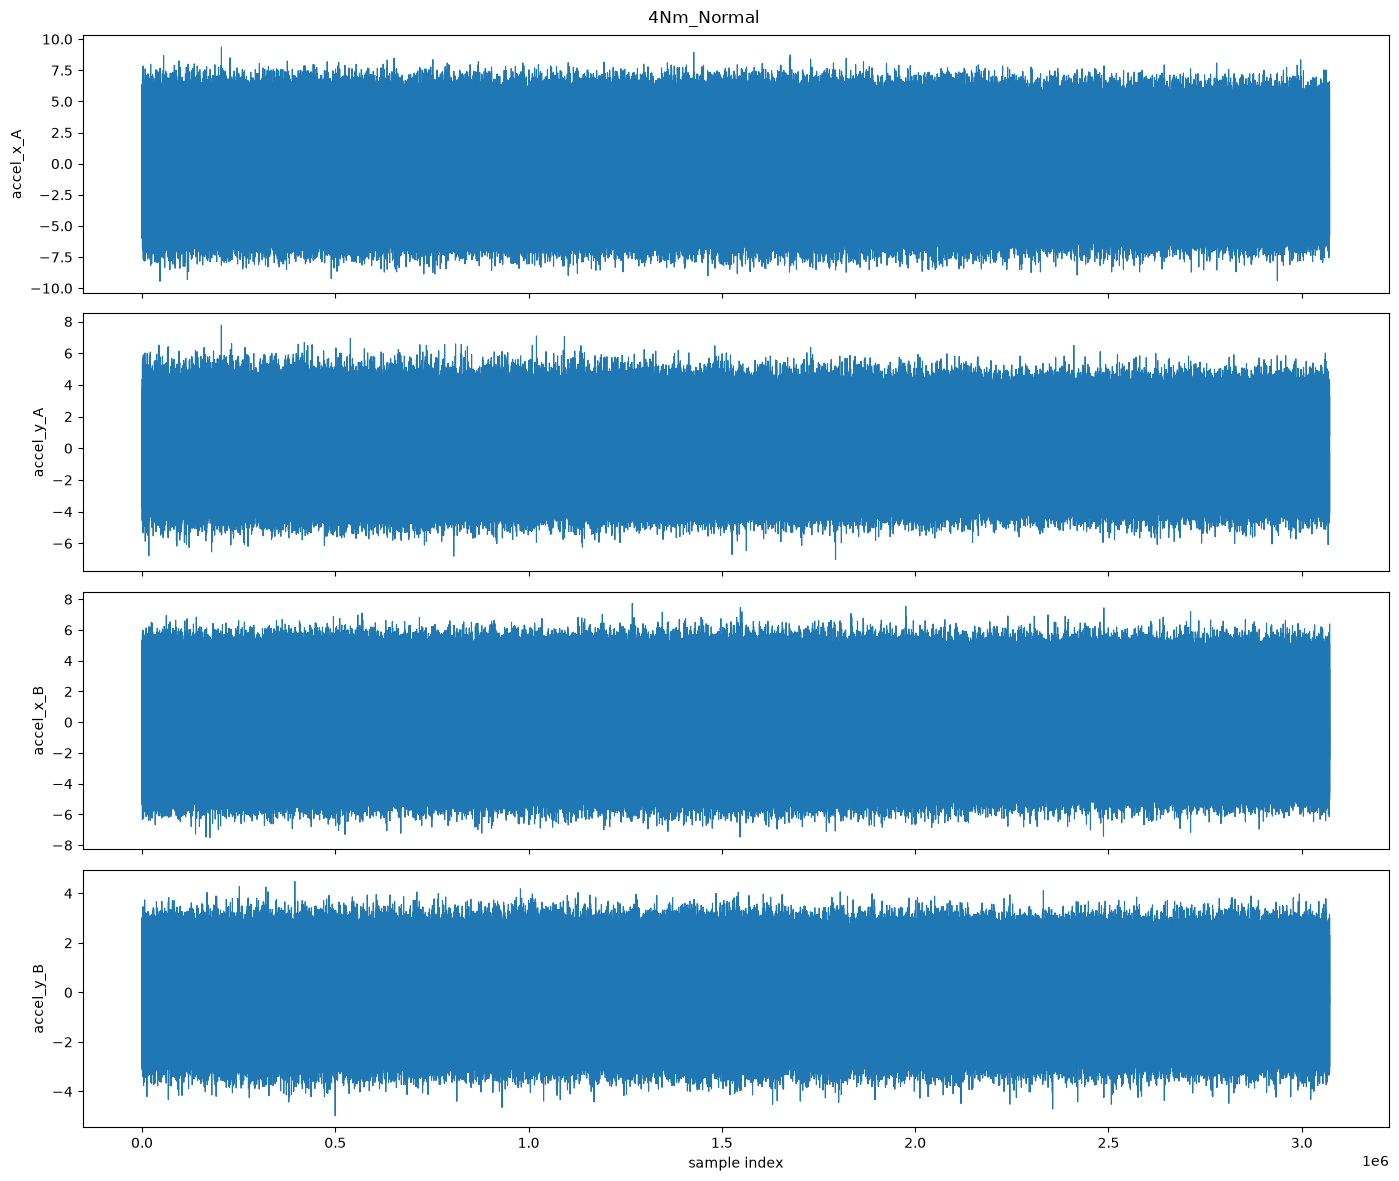

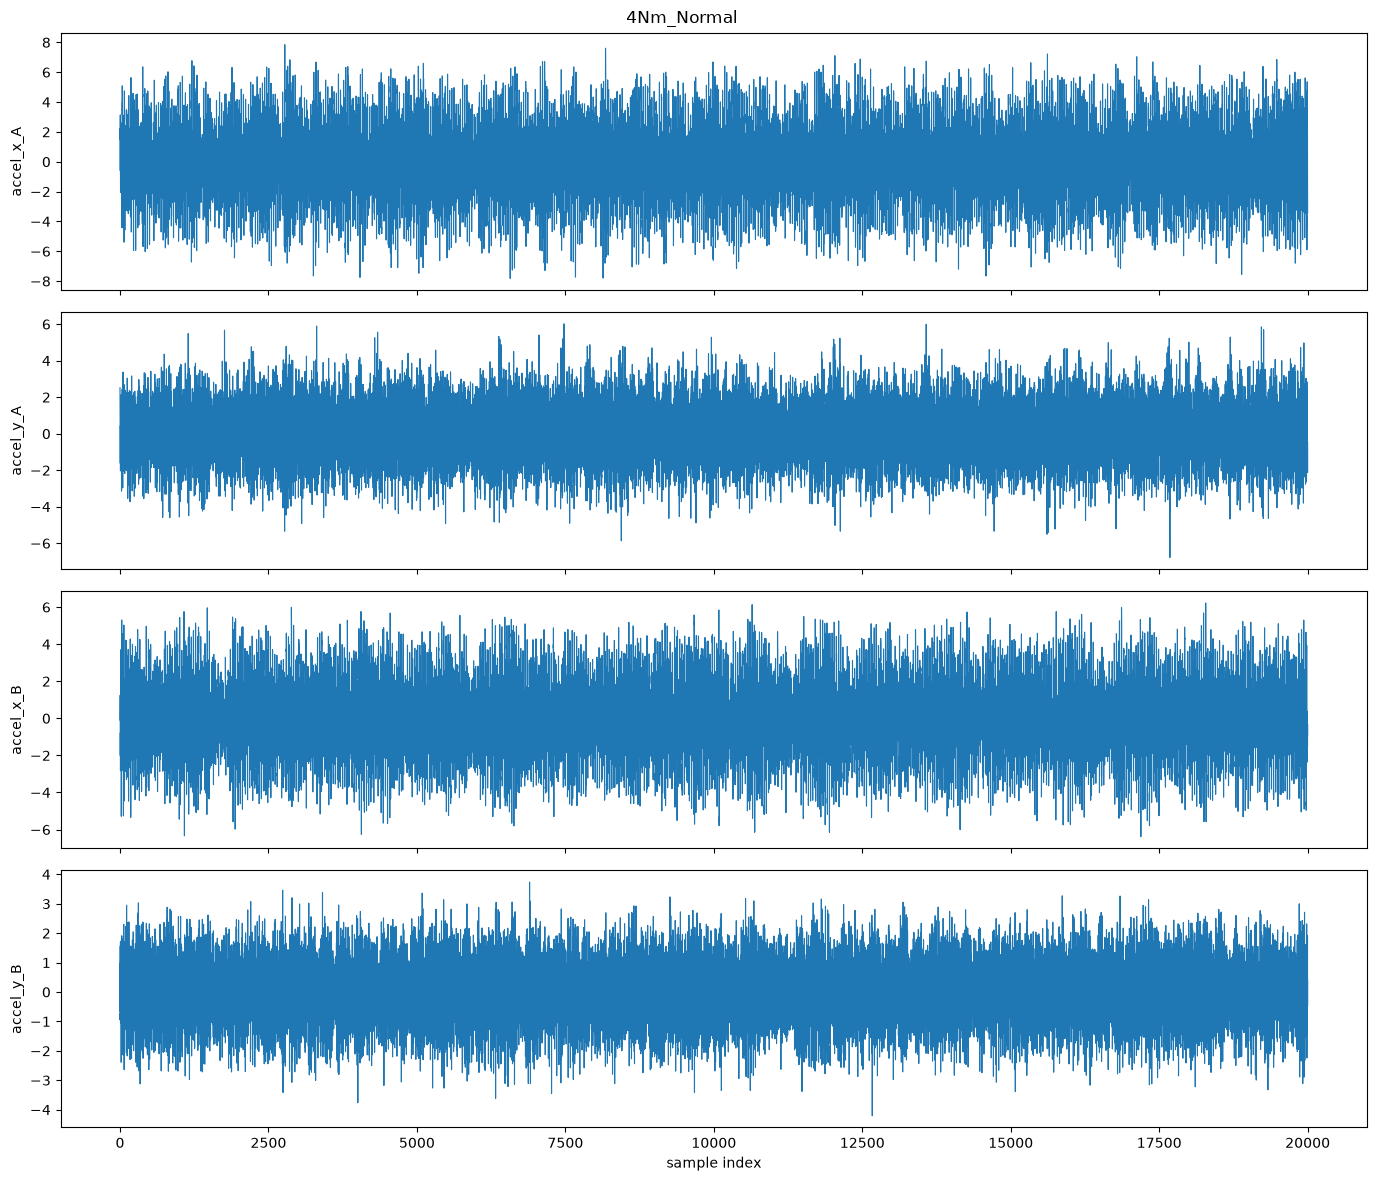

In [22]:
# apply b filter to vibration
co_hz=10000
df_vib = plot_mat_data("DataKAIST/vibration/4Nm_Normal.mat", cutoff_hz=co_hz)
df_vib = plot_mat_data("DataKAIST/vibration/4Nm_Normal.mat", subset=(0, 20000), cutoff_hz=co_hz)

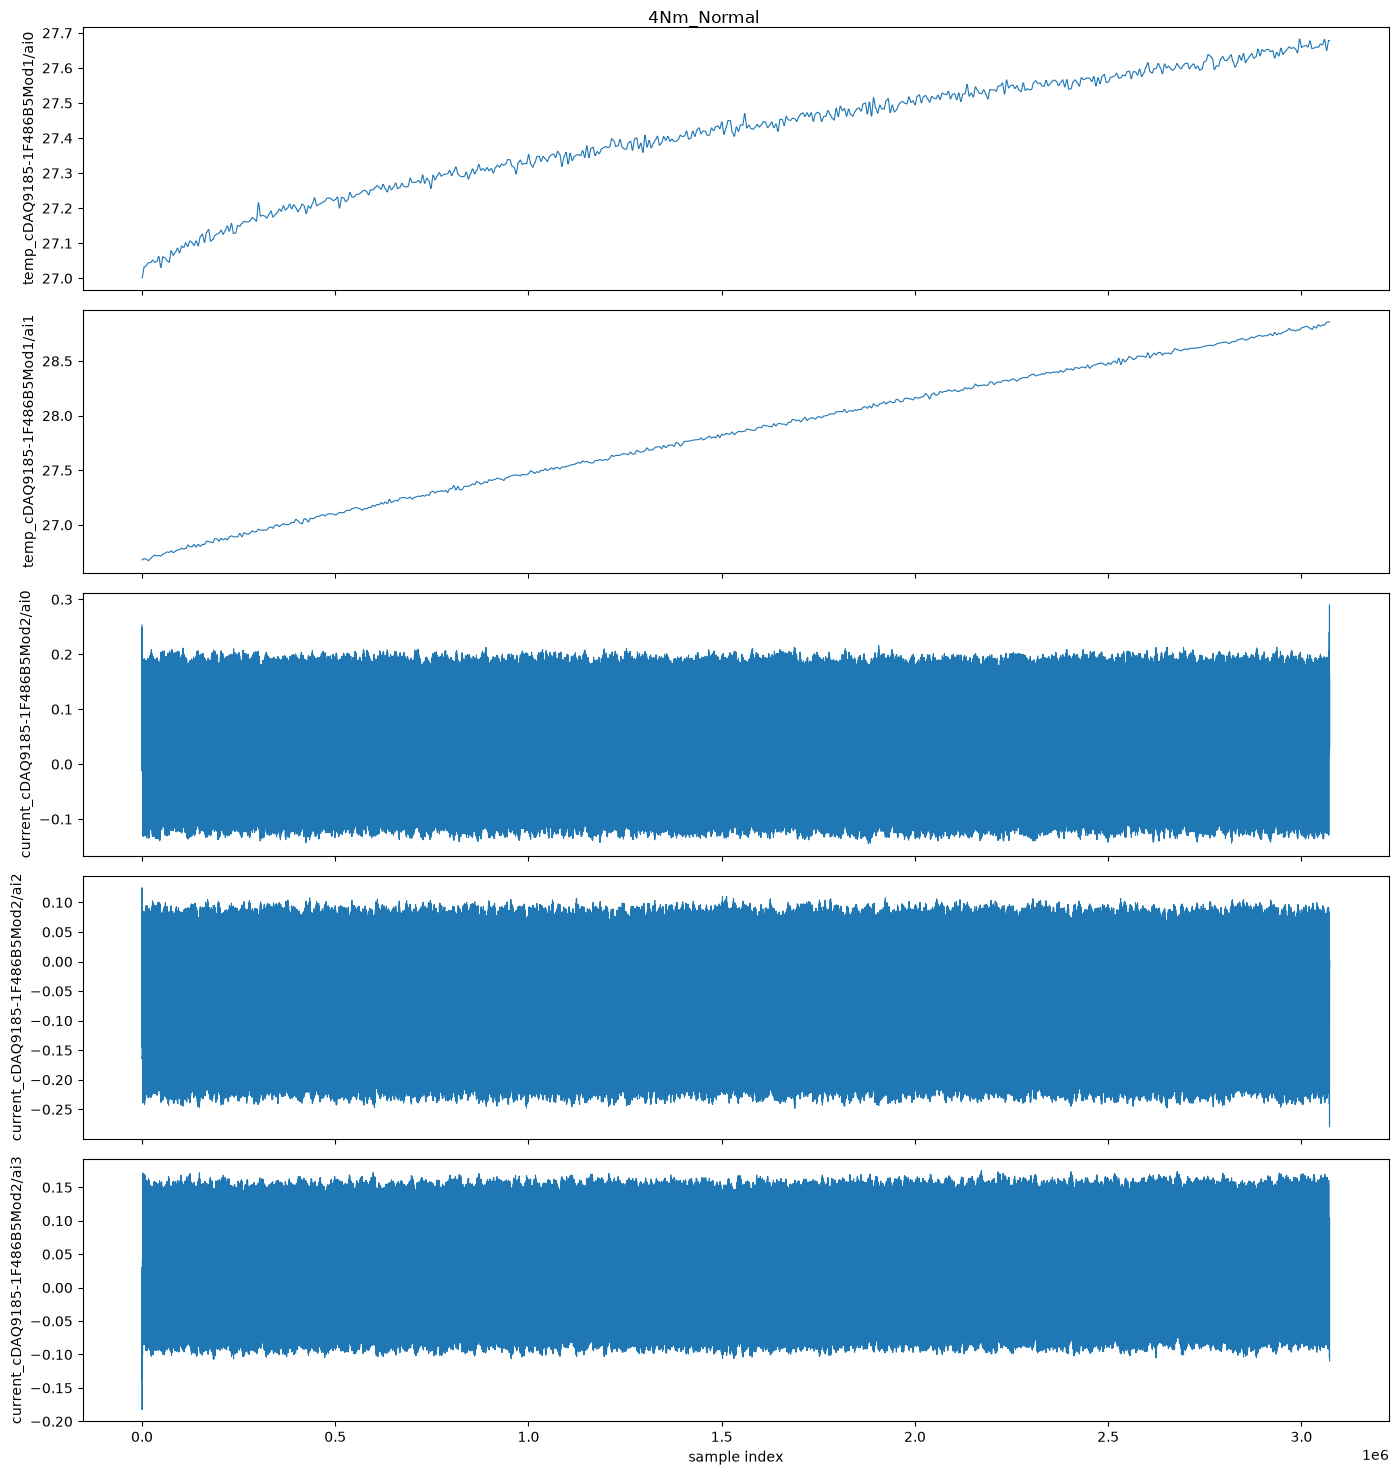

In [23]:
df_vib = plot_mat_data("DataKAIST/current,temp/4Nm_Normal.tdms", m_avg_window=4000)

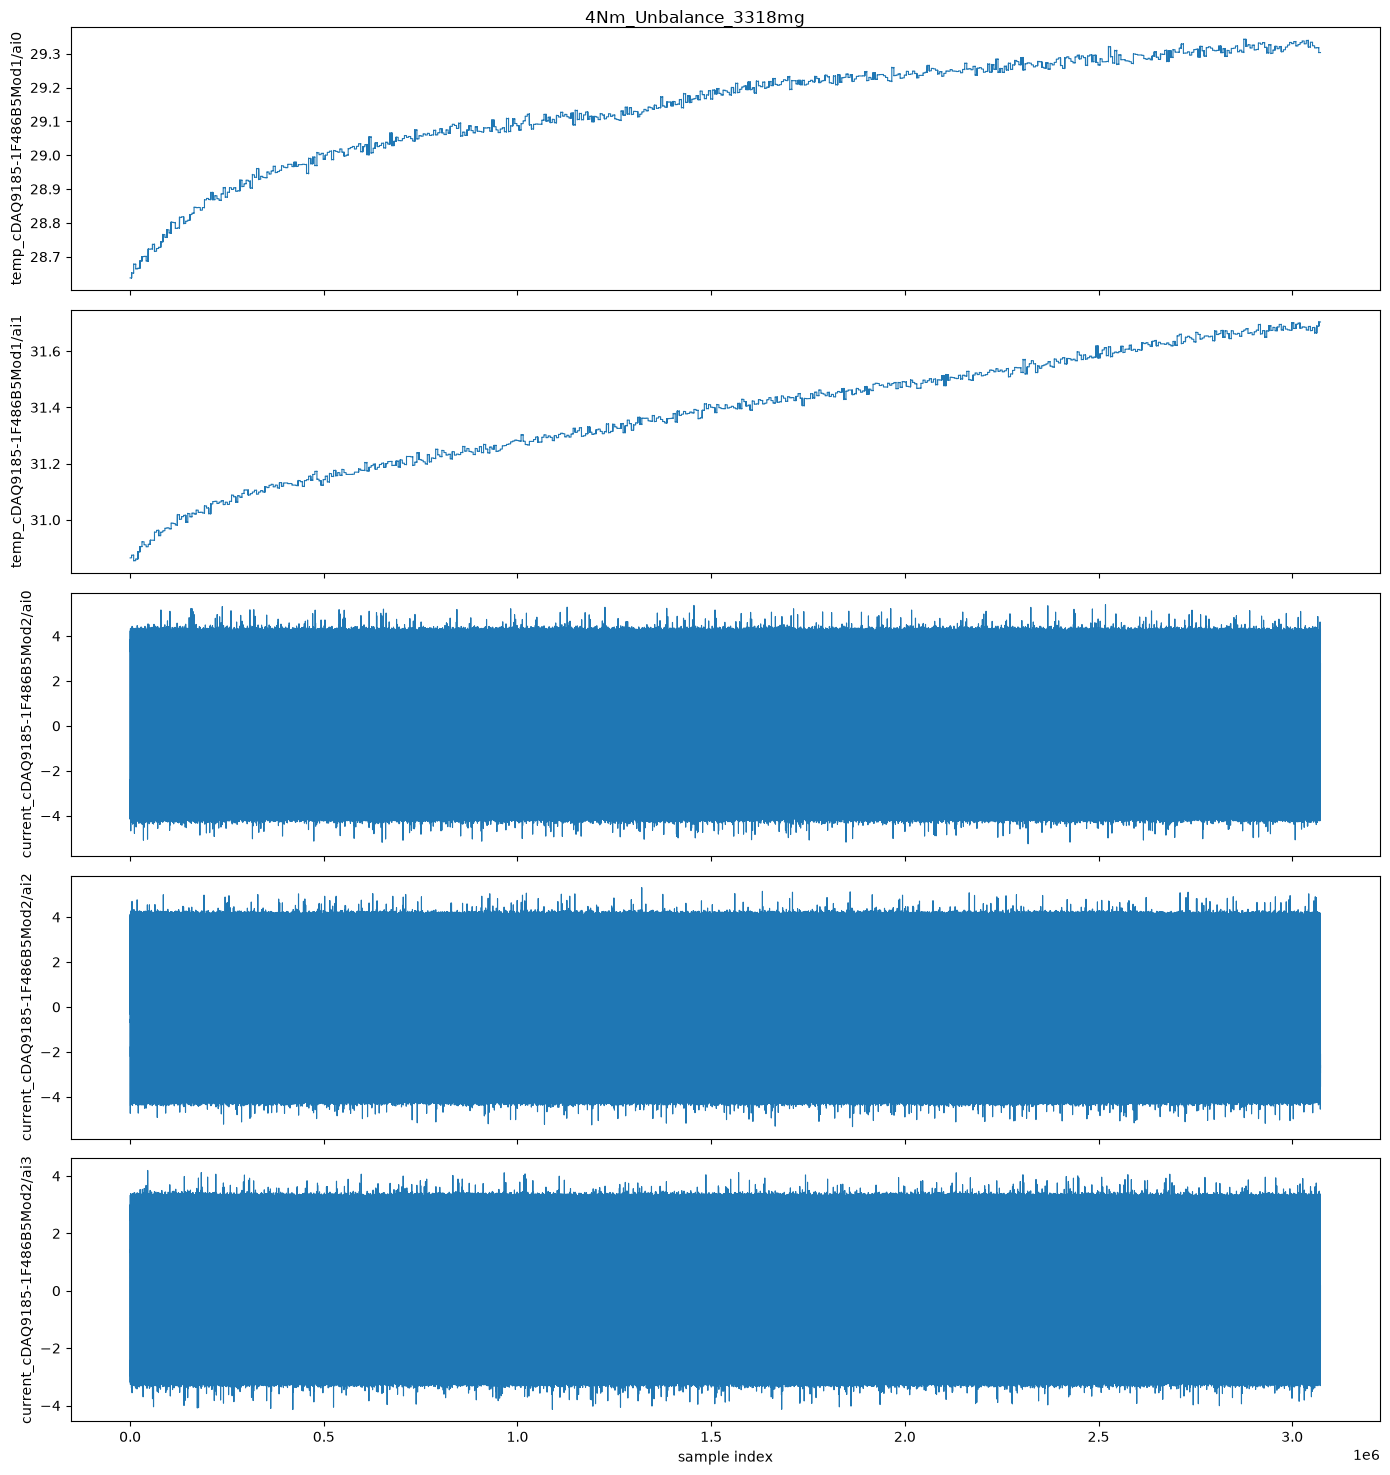

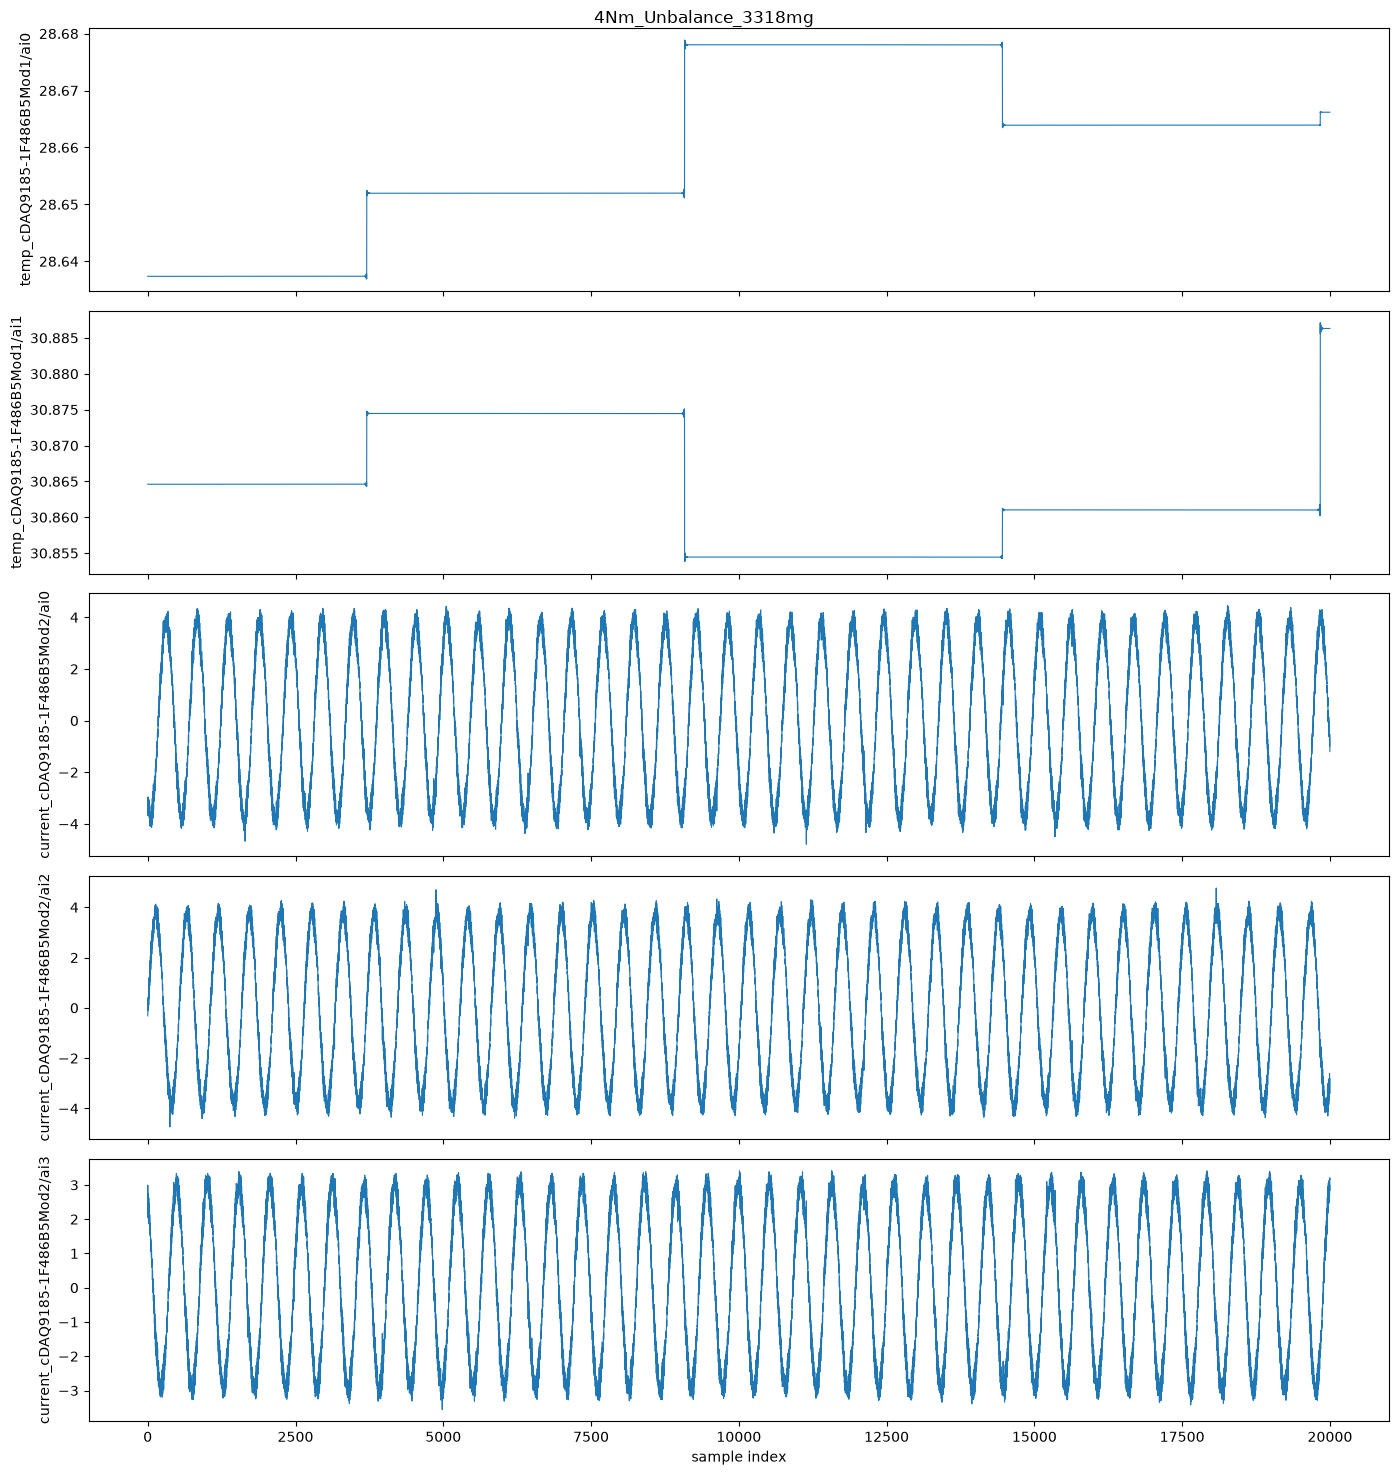

In [24]:
# apply bw filter to current
co_hz = 12000
df_vib = plot_mat_data("DataKAIST/current,temp/4Nm_Unbalance_3318mg.tdms", cutoff_hz=co_hz)
df_vib = plot_mat_data("DataKAIST/current,temp/4Nm_Unbalance_3318mg.tdms", subset=(0, 20000), cutoff_hz=co_hz)